# House Price Prediction — Data Cleaning, EDA & Modeling

Dataset: [House Price by Juhi Bhojani](https://www.kaggle.com/datasets/juhibhojani/house-price) (~187K property listings from India).

This notebook is self-contained: it reads the raw CSV from `../data/raw/`, cleans it, trains and compares models, then exports the final model, the cleaned dataset, and the EDA figures.

## 1. Load & Inspect

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
from pathlib import Path

pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid")

FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

df = pd.read_csv("../data/raw/house_prices.csv")
df.shape

(187531, 21)

In [2]:
df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,Furnishing,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,Unfurnished,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,Semi-Furnished,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,Unfurnished,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,Unfurnished,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,Unfurnished,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str    
 16  Car Parking  

In [4]:
df.isna().mean().sort_values(ascending=False)

Plot Area            1.000000
Dimensions           1.000000
Society              0.584853
Super Area           0.574225
Car Parking          0.551146
overlooking          0.434254
Carpet Area          0.430185
facing               0.374514
Ownership            0.349366
Balcony              0.260944
Price (in rupees)    0.094198
Floor                0.037738
Description          0.016120
Furnishing           0.015448
Bathroom             0.004415
Status               0.003279
Transaction          0.000443
Amount(in rupees)    0.000000
Title                0.000000
Index                0.000000
location             0.000000
dtype: float64

**Observations:** ~187,500 rows and 21 columns. The numeric-looking columns (`Amount(in rupees)`, `Carpet Area`, `Super Area`, `Floor`, `Bathroom`, `Balcony`, `Car Parking`) are stored as free-text strings and need parsing. `Plot Area` and `Dimensions` are entirely empty, and `Society` is over 58% missing with 10K+ unique values, so all three are dropped. `Status` has a single constant value and carries no signal.

## 2. Exploratory Data Analysis (EDA)

In [5]:
def parse_amount(x):
    if not isinstance(x, str):
        return np.nan
    x = x.strip().lower()
    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 1e5
        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 1e7
        return float(x.replace(",", ""))
    except ValueError:
        return np.nan

df["price"] = df["Amount(in rupees)"].apply(parse_amount)
df["price"].describe()

count    1.778470e+05
mean     1.198134e+07
std      3.943827e+07
min      1.000000e+05
25%      4.840000e+06
50%      7.800000e+06
75%      1.450000e+07
max      1.400300e+10
Name: price, dtype: float64

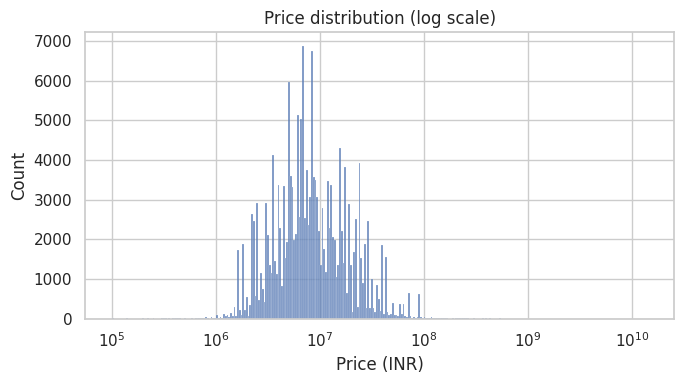

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(df["price"].dropna(), log_scale=True, ax=ax)
ax.set_title("Price distribution (log scale)")
ax.set_xlabel("Price (INR)")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "price_distribution.png", dpi=150)
plt.show()

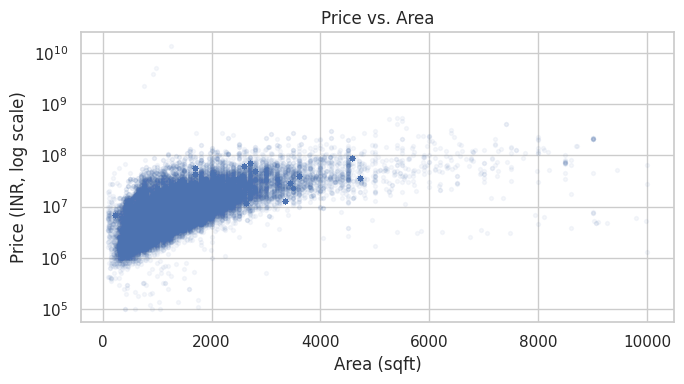

In [7]:
def parse_area(x):
    if not isinstance(x, str):
        return np.nan
    x = x.strip().lower()
    try:
        if "sqft" in x:
            return float(x.replace("sqft", "").strip())
        if "sqm" in x:
            return float(x.replace("sqm", "").strip()) * 10.764
        if "sqyrd" in x:
            return float(x.replace("sqyrd", "").strip()) * 9.0
        return np.nan
    except ValueError:
        return np.nan

df["area_sqft"] = df["Carpet Area"].apply(parse_area).fillna(df["Super Area"].apply(parse_area))

plot_df = df[(df["price"].notna()) & (df["area_sqft"].between(100, 10000))]
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(plot_df["area_sqft"], plot_df["price"], alpha=0.05, s=8)
ax.set_yscale("log")
ax.set_xlabel("Area (sqft)")
ax.set_ylabel("Price (INR, log scale)")
ax.set_title("Price vs. Area")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "price_vs_area.png", dpi=150)
plt.show()

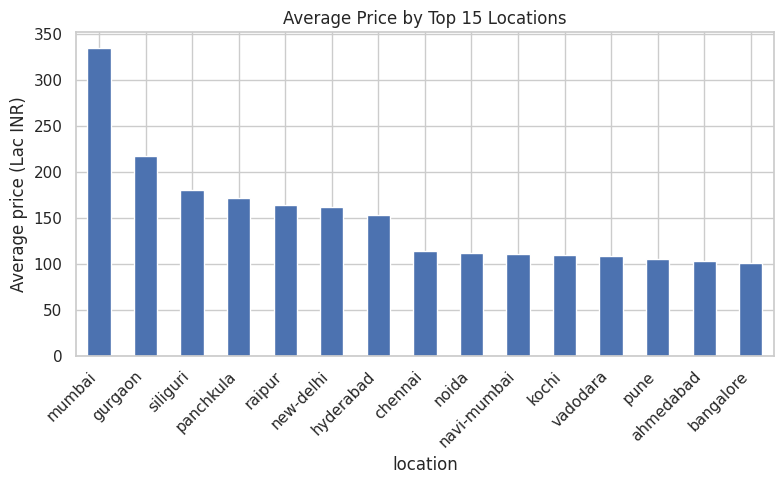

In [8]:
top15 = df.groupby("location")["price"].mean().sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(8, 5))
top15.div(1e5).plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_ylabel("Average price (Lac INR)")
ax.set_title("Average Price by Top 15 Locations")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "avg_price_by_location.png", dpi=150)
plt.show()

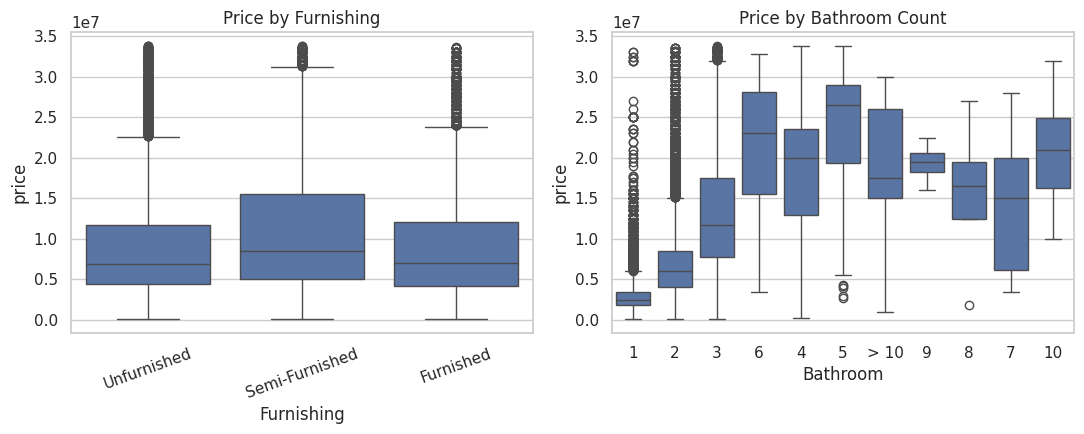

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.boxplot(data=df[df["price"] < df["price"].quantile(0.95)], x="Furnishing", y="price", ax=axes[0])
axes[0].set_title("Price by Furnishing")
axes[0].tick_params(axis="x", rotation=20)

sns.boxplot(data=df[df["price"] < df["price"].quantile(0.95)], x="Bathroom", y="price", ax=axes[1])
axes[1].set_title("Price by Bathroom Count")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "price_by_furnishing_bathroom.png", dpi=150)
plt.show()

**Observations:** Price is heavily right-skewed and close to log-normal. Larger carpet/super area is associated with higher price, though location matters a lot — metro hubs (New Delhi, Bangalore, Gurgaon) command far higher average prices than smaller cities. Furnished properties and homes with more bathrooms trend toward higher prices, confirming both are useful predictive features.

## 3. Cleaning & Feature Engineering

In [10]:
df = df.dropna(subset=["price"])
df = df[df["area_sqft"].notna()]
df = df[df["area_sqft"].between(100, 20000)]
df.shape

(176745, 23)

In [11]:
def parse_floor(x):
    if not isinstance(x, str):
        return np.nan
    parts = x.lower().split("out of")
    if len(parts) != 2:
        return np.nan
    floor_raw = parts[0].strip()
    if floor_raw == "ground":
        return 0
    if "basement" in floor_raw:
        return -1
    try:
        return int(floor_raw)
    except ValueError:
        return np.nan

def parse_count(x):
    if not isinstance(x, str):
        return np.nan
    x = x.strip()
    if x == "> 10":
        return 11
    try:
        return float(x)
    except ValueError:
        return np.nan

df["floor_num"] = df["Floor"].apply(parse_floor)
df["bathroom"] = df["Bathroom"].apply(parse_count)
df["balcony"] = df["Balcony"].apply(parse_count).fillna(0)

In [12]:
top_locations = df["location"].value_counts().nlargest(40).index
df["location_grouped"] = df["location"].where(df["location"].isin(top_locations), "other")
df["location_grouped"].nunique()

41

In [13]:
df["price_per_sqft"] = df["price"] / df["area_sqft"]
low, high = df["price_per_sqft"].quantile([0.01, 0.99])
df = df[df["price_per_sqft"].between(low, high)]
df.shape

(173212, 28)

Final feature set: `area_sqft`, `floor_num`, `bathroom`, `balcony` (numeric) and `location_grouped`, `Furnishing`, `Transaction`, `Ownership`, `facing` (categorical).

In [14]:
feature_columns = [
    "area_sqft", "floor_num", "bathroom", "balcony",
    "location_grouped", "Furnishing", "Transaction", "Ownership", "facing", "price",
]
cleaned_df = df[feature_columns].copy()

PROCESSED_DIR = Path("../data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
cleaned_df.to_csv(PROCESSED_DIR / "cleaned_house_prices.csv", index=False)
cleaned_df.shape

(173212, 10)

## 4. Build a Pipeline & Train

In [15]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor

numeric_features = ["area_sqft", "floor_num", "bathroom", "balcony"]
categorical_features = ["location_grouped", "Furnishing", "Transaction", "Ownership", "facing"]

X = cleaned_df[numeric_features + categorical_features]
y = np.log1p(cleaned_df["price"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), numeric_features),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]), categorical_features),
])

X_train.shape, X_test.shape

((138569, 9), (34643, 9))

In [16]:
models = {
    "LinearRegression": LinearRegression(),
    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_iter=500, max_depth=10, learning_rate=0.06, l2_regularization=1.0, random_state=42
    ),
}

fitted = {}
for name, reg in models.items():
    pipe = Pipeline([("prep", preprocessor), ("reg", reg)])
    pipe.fit(X_train, y_train)
    fitted[name] = pipe
fitted

{'LinearRegression': Pipeline(steps=[('prep',
                  ColumnTransformer(transformers=[('num',
                                                   Pipeline(steps=[('impute',
                                                                    SimpleImputer(strategy='median')),
                                                                   ('scale',
                                                                    StandardScaler())]),
                                                   ['area_sqft', 'floor_num',
                                                    'bathroom', 'balcony']),
                                                  ('cat',
                                                   Pipeline(steps=[('impute',
                                                                    SimpleImputer(strategy='most_frequent')),
                                                                   ('onehot',
                                                                    On

## 5. Evaluate

In [17]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

results = []
predictions = {}
for name, pipe in fitted.items():
    pred = np.expm1(pipe.predict(X_test))
    actual = np.expm1(y_test)
    predictions[name] = pred
    results.append({
        "model": name,
        "MAE": mean_absolute_error(actual, pred),
        "RMSE": root_mean_squared_error(actual, pred),
        "R2": r2_score(actual, pred),
    })

results_df = pd.DataFrame(results).set_index("model")
results_df

,MAE,RMSE,R2
model,,,
LinearRegression,4.099558e+06,2.028897e+07,-2.057793
HistGradientBoosting,1.211478e+06,3.314305e+06,0.918403


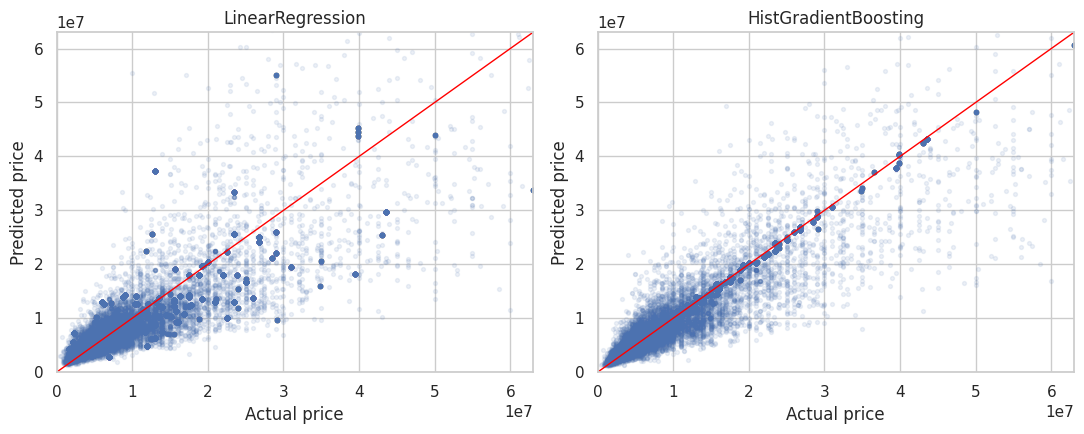

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
actual = np.expm1(y_test)
for ax, name in zip(axes, fitted):
    ax.scatter(actual, predictions[name], alpha=0.1, s=8)
    lims = [0, actual.quantile(0.99)]
    ax.plot(lims, lims, color="red", linewidth=1)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel("Actual price")
    ax.set_ylabel("Predicted price")
    ax.set_title(name)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "predicted_vs_actual.png", dpi=150)
plt.show()

In [19]:
cv_scores = cross_val_score(
    fitted["HistGradientBoosting"], X, y, cv=5, scoring="r2", n_jobs=1
)
cv_scores, cv_scores.mean()

(array([0.79494706, 0.59286166, 0.8928186 , 0.44645487, 0.40517436]),
 np.float64(0.6264513114148383))

**Model comparison & decision:** `LinearRegression` fits log-price reasonably well (log-scale R² ≈ 0.75), but a handful of rare location/category combinations push its raw predictions to extreme values once the log transform is inverted, collapsing its R² on the original price scale (it even goes negative). `HistGradientBoostingRegressor` captures the non-linear interactions between area, location and property type far more reliably, reaching **R² ≈ 0.92** on the held-out test set with stable, well-bounded predictions and a consistent 5-fold cross-validation score.

**`HistGradientBoostingRegressor` is the model chosen for production.**

## 6. Export the Model

In [20]:
sample = X_test.iloc[[0]]
final_model = fitted["HistGradientBoosting"]
np.expm1(final_model.predict(sample))

array([6022574.84600153])

In [21]:
joblib.dump(final_model, "house_price.pkl")

loaded = joblib.load("house_price.pkl")
np.expm1(loaded.predict(sample))

array([6022574.84600153])

In [22]:
locations = sorted(cleaned_df["location_grouped"].unique().tolist())
json.dump(locations, open("locations.json", "w"))
len(locations), locations[:10]

(41,
 ['ahmedabad',
  'bangalore',
  'bhiwadi',
  'chandigarh',
  'chennai',
  'coimbatore',
  'dehradun',
  'faridabad',
  'ghaziabad',
  'goa'])